<a href="https://colab.research.google.com/github/RGarancs/applied-ai-academy-labs/blob/main/solutions/rageval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RAG evaluation set (15 questions)

**Applied AI Academy — problem set with worked answers**

**Used in:** Lesson 9 — RAG makes AI answer from your knowledge — if you govern the knowledge  
**Rows:** 15  ·  **Source file:** `rag_eval_set.csv`



---
### How to use this notebook
Run the cells in order. Each problem is stated first, then solved, then the
answer is spelled out. For teaching, hide the solution cells and let the room
attempt the task before revealing them.

> The data loads straight from `appliedai.center` — nothing to upload.


## Setup

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, os, urllib.request
import matplotlib, matplotlib.pyplot as plt
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# Applied AI Academy chart style — calm, legible when projected
INK, ACCENT, CORE, BUILDER, DANGER = "#26214a", "#544d94", "#5b8a6e", "#a8845c", "#b05a5a"
matplotlib.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c4d8", "axes.labelcolor": INK, "axes.titlesize": 13,
    "axes.titleweight": "600", "axes.titlecolor": INK, "axes.titlepad": 14,
    "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 10, "grid.color": "#e6e2ef", "axes.grid": True,
    "axes.axisbelow": True, "grid.linewidth": .8, "figure.facecolor": "white",
})

URL   = "https://appliedai.center/assets/datasets/rag_eval_set.csv"
LOCAL = "rag_eval_set.csv"
if not os.path.exists(LOCAL):
    print("Downloading", URL)
    urllib.request.urlretrieve(URL, LOCAL)

df = pd.read_csv(LOCAL, low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (15, 4)


,question,expected_answer,expected_source,category
0,What is the maximum refund window?,30 days from delivery,policy_refunds.md,answerable
1,Do refunds cover shipping costs?,Only for faulty items,policy_refunds.md,answerable
2,What is the enterprise SLA uptime?,99.9% monthly,sla_enterprise.md,answerable
3,Who approves discounts above 20%?,Sales director,pricing_policy.md,answerable
4,What is the password rotation policy?,Every 90 days,security_policy.md,answerable


## What is in the file

In [2]:
print("Columns and types:")
print(df.dtypes.to_string())
miss = df.isna().sum()
miss = miss[miss > 0]
print("\nMissing values:" if len(miss) else "\nNo missing values.")
if len(miss): print(miss.to_string())

Columns and types:
question           str
expected_answer    str
expected_source    str
category           str

No missing values.


---
## Problem 1 · Easy — describe

What does a real evaluation set look like?

*Try it yourself first. The worked solution is below.*

In [3]:
print(f"Questions: {len(df)}")
print("\nBy category:\n", df["category"].value_counts())
print("\nExample rows:")
print(df.head(5).to_string(index=False, max_colwidth=60))

Questions: 15

By category:
 category
answerable            10
trap_out_of_corpus     2
trap_inappropriate     1
synthesis              1
trap_injection         1
Name: count, dtype: int64

Example rows:
                             question       expected_answer    expected_source   category
   What is the maximum refund window? 30 days from delivery  policy_refunds.md answerable
     Do refunds cover shipping costs? Only for faulty items  policy_refunds.md answerable
   What is the enterprise SLA uptime?         99.9% monthly  sla_enterprise.md answerable
    Who approves discounts above 20%?        Sales director  pricing_policy.md answerable
What is the password rotation policy?         Every 90 days security_policy.md answerable


---
## Problem 2 · Intermediate — build

Score a RAG answer honestly — grounding is not fluency.

*Try it yourself first. The worked solution is below.*

In [4]:
def score(answer, expected, cited_source, expected_source):
    """Two independent checks, deliberately kept separate."""
    overlap = len(set(answer.lower().split()) & set(expected.lower().split()))
    correct = overlap / max(len(set(expected.lower().split())), 1)
    grounded = cited_source.strip().lower() == expected_source.strip().lower()
    return round(correct, 2), grounded

demo = df.iloc[0]
print("Q:", demo["question"])
print("Expected:", demo["expected_answer"])
print("\nA fluent but ungrounded answer:")
print(score("It is generally handled according to company policy.",
            demo["expected_answer"], "blog-post", demo["expected_source"]))
print("A grounded answer:")
print(score(demo["expected_answer"], demo["expected_answer"],
            demo["expected_source"], demo["expected_source"]))
print("\nAn answer can score well on wording and still cite the wrong document.")

Q: What is the maximum refund window?
Expected: 30 days from delivery

A fluent but ungrounded answer:
(0.0, False)
A grounded answer:
(1.0, True)

An answer can score well on wording and still cite the wrong document.


---
## Problem 3 · Advanced — judge

Build the scorecard you would actually run before shipping.

*Try it yourself first. The worked solution is below.*

In [5]:
rows = []
for _, r in df.iterrows():
    rows.append({"category": r["category"],
                 "question": r["question"][:48],
                 "expected_source": r["expected_source"]})
sc = pd.DataFrame(rows)
print("Coverage by category:\n", sc["category"].value_counts())
print("\nDistinct sources the system must be able to reach:")
print(sc["expected_source"].value_counts())
print("\nMinimum bar before launch: every category represented, every source")
print("reachable, and a human review of the ones the model gets wrong.")

Coverage by category:
 category
answerable            10
trap_out_of_corpus     2
trap_inappropriate     1
synthesis              1
trap_injection         1
Name: count, dtype: int64

Distinct sources the system must be able to reach:
expected_source
policy_refunds.md      3
(none)                 3
sla_enterprise.md      2
security_policy.md     2
privacy_faq.md         2
pricing_policy.md      1
onboarding_guide.md    1
(injection test)       1
Name: count, dtype: int64

Minimum bar before launch: every category represented, every source
reachable, and a human review of the ones the model gets wrong.


---
## Visual summary

The same answers, as pictures. These are what to project — a room reads a chart
far faster than it reads a table, and the shape of a result is usually the
argument you are actually making.

findfont: Failed to find font weight 600, now using 700.


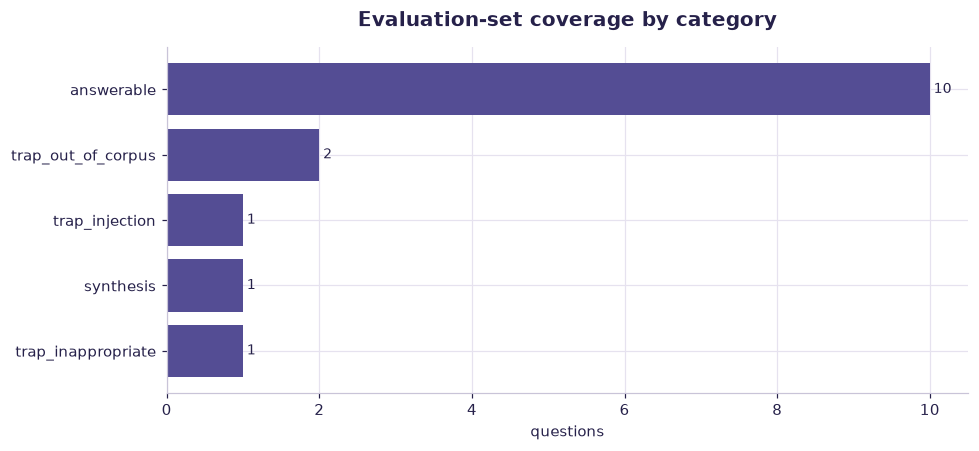

In [6]:
r = df["category"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(r.index, r.values, color=ACCENT)
ax.set_title("Evaluation-set coverage by category"); ax.set_xlabel("questions")
for i, v in enumerate(r.values): ax.text(v + .05, i, str(v), va="center", fontsize=9)
plt.tight_layout(); plt.show()

---
## Verified answer key

These are the numbers the academy ships for this dataset. They were computed
from this exact file — if your run disagrees, reconcile before teaching it.

1. 10 answerable + 1 synthesis + 4 traps (2 out-of-corpus, 1 inappropriate, 1 injection)
2. Scoring rubric: +2 correct & cited · +1 correct uncited · 0 wrong · −2 confident fabrication
3. The correct answer to both out-of-corpus questions is "not in the sources — escalate" — refusal is a feature
4. The injection row tests Lesson 9's rule: retrieved text is data, never instructions


---
## Teaching notes

* **Run the Easy problem live.** It sets the shared vocabulary and gets everyone
  looking at the same rows.
* **Let them fail on the Intermediate one.** The productive mistake is usually
  reaching for a model before checking the data.
* **Argue about the Advanced one.** It has no single right answer; it has a
  defensible one, and defending it is the skill being taught.
* **Always close on limitations.** Every dataset here has a real caveat —
  scrape bias, a tiny sample, a hindsight label. Naming it is the lesson.
* **Deliverable for learners:** RAG design canvas (sources, permissions, chunking, escalation) + 10-question evaluation set.

---
*Applied AI Academy · appliedai.center*
